# Exploration des Données Multi-Omiques (Pan-Cancer & BRCA)

Ce notebook utilise les nouveaux outils de chargement pour explorer le dataset Pan-Cancer fusionné avec les données cliniques BRCA.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import joblib
import importlib

# Robust path setup
project_root = Path(os.getcwd())
if project_root.name == 'notebooks':
    project_root = project_root.parent

src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"Racine du projet : {project_root}")

# Import common components
from xai_clinical.data.pancan_loader import PANCANLoader, BRCALoader, PANCANBRCAFusion


Racine du projet : c:\Users\nidha\Desktop\xai_clinical_prediction


## 1. Initialisation des Chargeurs

Nous configurons les chargeurs pour pointer vers les données brutes.

In [2]:
pancan_dir = project_root / "data" / "raw" / "pancan"
brca_dir = project_root / "data" / "raw" / "brca_tcga"

# Initialisation (sans filtre pour charger tout le Pan-Cancer)
pancan_loader = PANCANLoader(str(pancan_dir), cancer_type=None)
brca_loader = BRCALoader(str(brca_dir))

## 2. Chargement des Données Cliniques (BRCA)

Ici, nous utilisons la correction qui sélectionne `PATIENT_ID` comme index.

In [3]:
clinical_df = brca_loader.get_merged_clinical()
print(f"Données cliniques chargées : {clinical_df.shape}")
display(clinical_df.head(2))

# Extraction de la cible (Décès < 24 mois)
target = brca_loader.extract_survival_target(clinical_df, cutoff_months=24)
print("\nDistribution de la cible de survie :")
print(target.value_counts())

2026-04-29 22:57:11,452 - xai_clinical.data.pancan_loader - INFO - Clinical patient: (1097, 110)


2026-04-29 22:57:11,476 - xai_clinical.data.pancan_loader - INFO - Clinical sample: (1108, 26)
2026-04-29 22:57:11,490 - xai_clinical.data.pancan_loader - INFO - Clinical merged: (1108, 136)
Données cliniques chargées : (1108, 136)


,OTHER_PATIENT_ID,FORM_COMPLETION_DATE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,MENOPAUSE_STATUS,RACE,ETHNICITY,HISTORY_OTHER_MALIGNANCY,HISTORY_NEOADJUVANT_TRTYN,...,SAMPLE_TYPE_ID,SHORTEST_DIMENSION,TIME_BETWEEN_CLAMPING_AND_FREEZING,TIME_BETWEEN_EXCISION_AND_FREEZING,VIAL_NUMBER,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,TMB_NONSYNONYMOUS
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU,6E7D5EC6-A469-467C-B748-237353C23416,1/13/14,NO,YES,Female,Pre (<6 months since LMP AND no prior bilatera...,WHITE,NOT HISPANIC OR LATINO,No,No,...,1,[Not Available],[Not Available],[Not Available],A,BRCA,[Not Available],[Not Available],Matched,NaN
TCGA-3C-AALI,55262FCB-1B01-4480-B322-36570430C917,7/28/14,NO,YES,Female,Post (prior bilateral ovariectomy OR >12 mo si...,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,No,No,...,1,[Not Available],[Not Available],[Not Available],A,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Matched,NaN


2026-04-29 22:57:11,517 - xai_clinical.data.pancan_loader - INFO - Cible survie calculée (cut-off 24m): {0: 1062, 1: 39}

Distribution de la cible de survie :
0    1062
1      39
Name: count, dtype: int64


## 3. Chargement de l'Expression Génique (Pan-Cancer)

Attention : Le fichier fait 1.8 Go. Le chargement peut prendre du temps.

In [4]:
expression_df = pancan_loader.load_gene_expression()
print(f"Données d'expression chargées : {expression_df.shape}")

2026-04-29 22:57:11,528 - xai_clinical.data.pancan_loader - INFO - Chargement PANCAN expression: c:\Users\nidha\Desktop\xai_clinical_prediction\data\raw\pancan\EBPlusPlusAdjustPANCAN.tsv


MemoryError: Unable to allocate 1.69 GiB for an array with shape (11069, 20531) and data type float64

## 4. Fusion et Alignement

On aligne les patients communs entre les gènes (Pan-Cancer) et la clinique (BRCA).

In [ ]:
fusion = PANCANBRCAFusion(pancan_loader, brca_loader)
fused_df = fusion.fuse_expression_clinical(expression_df, clinical_df, target)

print(f"Données fusionnées : {fused_df.shape}")
if 'TARGET' in fused_df.columns:
    print("\nDistribution finale dans le dataset fusionné :")
    print(fused_df['TARGET'].value_counts())

2026-04-26 18:49:27,459 - xai_clinical.data.pancan_loader - INFO - Échantillons communs PANCAN+BRCA: 1097
2026-04-26 18:49:27,538 - xai_clinical.data.pancan_loader - INFO - Données fusionnées: (1097, 5137)
Données fusionnées : (1097, 5137)

Distribution finale dans le dataset fusionné :
TARGET
0    1058
1      39
Name: count, dtype: int64


## 5. Visualisation Rapide

Comparaison de l'expression de quelques gènes clés (ex: ESR1 pour le cancer du sein) selon la survie.

2026-04-26 18:49:27,649 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-26 18:49:27,662 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


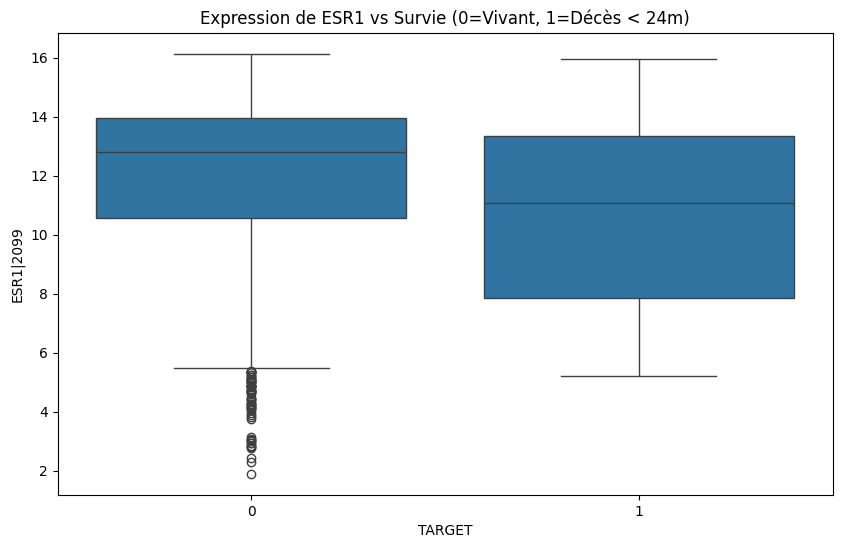

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

esr1_col = next((c for c in fused_df.columns if c.startswith('ESR1|')), 'ESR1')
if esr1_col in fused_df.columns and 'TARGET' in fused_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='TARGET', y=esr1_col, data=fused_df)
    plt.title("Expression de ESR1 vs Survie (0=Vivant, 1=Décès < 24m)")
    plt.show()
else:
    print("ESR1 non trouvé dans les colonnes ou fusion échouée.")
